

This project was independently implemented as a learning-focused research exercise using publicly available Indian air quality data.



# Explainable Machine Learning for AQI Prediction


**Domain:** Machine Learning / Environmental Analytics  
**Tools:** Python, Scikit-learn, SHAP, Google Colab  

---

###  Objective
To predict Air Quality Index (AQI) using environmental pollutant data and apply explainable machine learning techniques to interpret model predictions.

##    Project Workflow

1. Dataset Description  
2. Data Exploration & Cleaning  
3. Feature Selection  
4. Model Building  
5. Model Evaluation  
6. Explainable AI (SHAP)  
7. Results & Conclusion


In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


## 1. Dataset Description

The dataset contains daily air quality information for an Indian city, including key pollutants such as PM2.5, PM10, NO₂, SO₂, CO, and O₃.  
The target variable is Air Quality Index (AQI), which represents overall air pollution levels.



In [4]:
import pandas as pd

df = pd.read_csv("Delhi_AQI_Dataset.csv")
df.head()


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Delhi,01-01-2018,406,223.3,438.48,336.98,462.84,4.26,385.7
1,Delhi,02-01-2018,418,229.9,451.44,346.94,476.52,4.39,397.1
2,Delhi,03-01-2018,382,210.1,412.56,317.06,435.48,4.01,362.9
3,Delhi,04-01-2018,366,201.3,395.28,303.78,417.24,3.84,347.7
4,Delhi,05-01-2018,390,214.5,421.20,323.70,444.60,4.10,370.5


In [5]:
df.shape

(2191, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    2191 non-null   object 
 1   Date    2191 non-null   object 
 2   AQI     2191 non-null   int64  
 3   PM2.5   2191 non-null   float64
 4   PM10    2191 non-null   float64
 5   NO2     2191 non-null   float64
 6   SO2     2191 non-null   float64
 7   CO      2191 non-null   float64
 8   O3      2191 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 154.2+ KB


In [7]:
df.describe()

,AQI,PM2.5,PM10,NO2,SO2,CO,O3
count,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000
mean,208.285714,114.557143,224.948571,172.877143,237.445714,2.187307,197.871429
std,106.614654,58.638060,115.143827,88.490163,121.540706,1.119494,101.283922
min,41.000000,22.550000,44.280000,34.030000,46.740000,0.430000,38.950000
25%,117.000000,64.350000,126.360000,97.110000,133.380000,1.230000,111.150000
50%,190.000000,104.500000,205.200000,157.700000,216.600000,2.000000,180.500000
75%,289.000000,158.950000,312.120000,239.870000,329.460000,3.030000,274.550000
max,494.000000,271.700000,533.520000,410.020000,563.160000,5.190000,469.300000


## 2. Data Cleaning & Preprocessing

Environmental datasets often contain missing or noisy values.  
To ensure robust model training, missing values were handled using mean imputation.

In [8]:
df.isnull().sum()

,0
City,0
Date,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


In [9]:
df.drop(df.filter(regex="Unnamed"),axis=1,inplace=True)

In [10]:
df.isnull().sum()

,0
City,0
Date,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


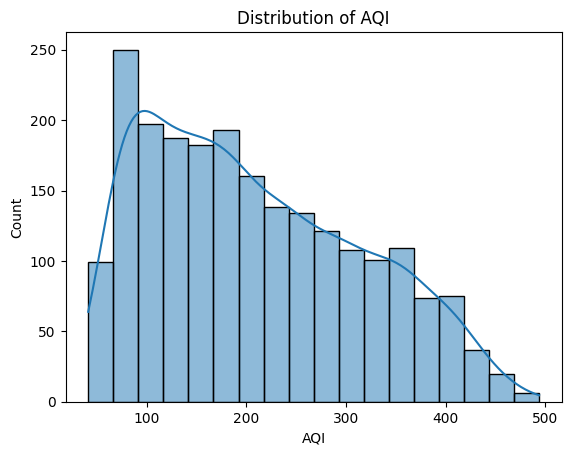

In [11]:

plt.figure()
sns.histplot(df['AQI'], kde=True)
plt.title("Distribution of AQI")
plt.show()


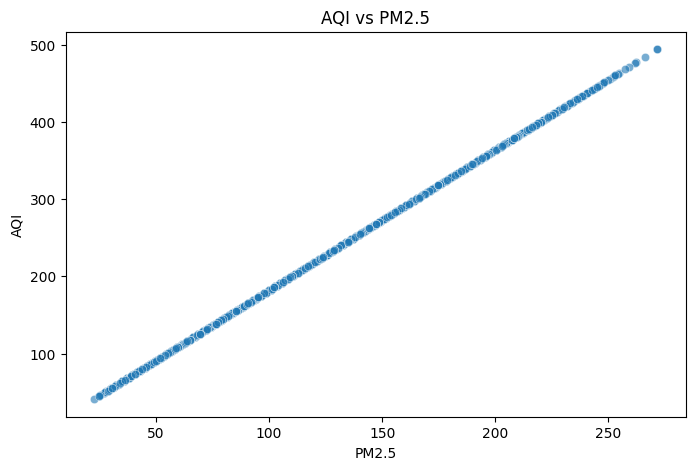

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['PM2.5'], y=df['AQI'], alpha=0.6)
plt.title("AQI vs PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()


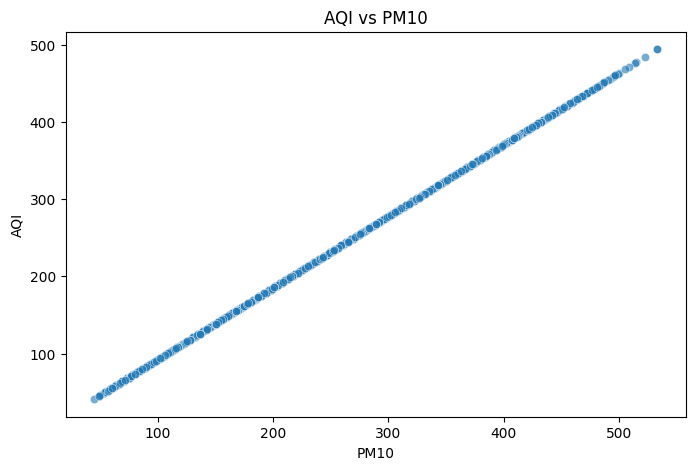

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['PM10'], y=df['AQI'], alpha=0.6)
plt.title("AQI vs PM10")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.show()


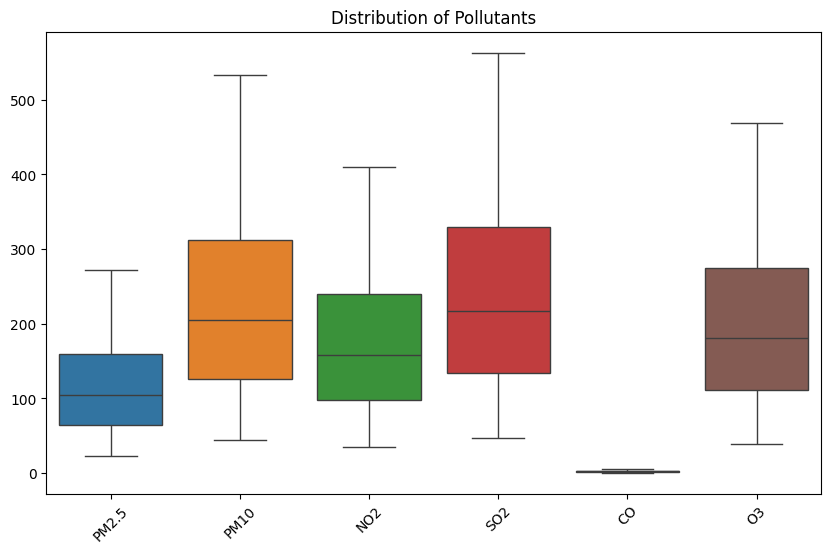

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']])
plt.title("Distribution of Pollutants")
plt.xticks(rotation=45)
plt.show()


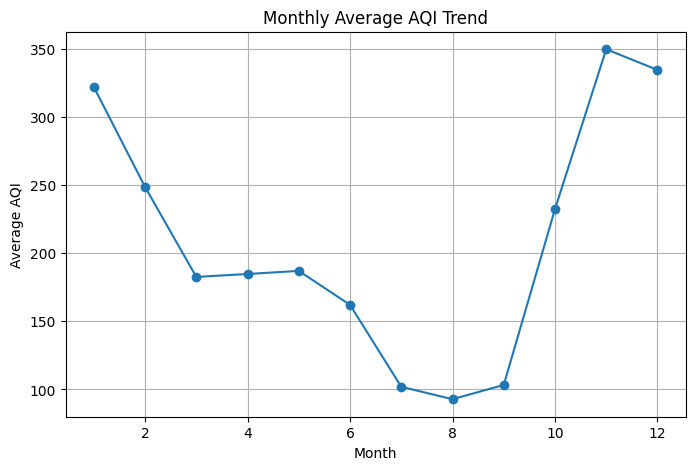

In [16]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month

monthly_aqi = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,5))
monthly_aqi.plot(marker='o')
plt.title("Monthly Average AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()


## 3. Correlation Analysis

The correlation heatmap illustrates relationships between pollutant concentrations and AQI.  
Strong positive correlations indicate pollutants that significantly contribute to poor air quality.


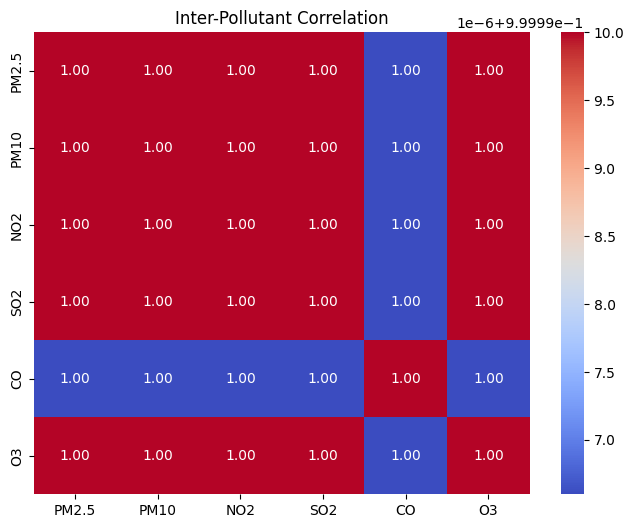

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (VERY IMPORTANT)
df = pd.read_csv("Delhi_AQI_Dataset.csv")

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

corr = df[pollutants].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Inter-Pollutant Correlation")
plt.show()



**Observation:**  
PM2.5 and PM10 show the strongest correlation with AQI, indicating particulate matter as the dominant pollution contributor.


In [18]:
df_ml = df.drop(columns=['City', 'Date'], errors='ignore')
df_ml.head()

,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,406,223.3,438.48,336.98,462.84,4.26,385.7
1,418,229.9,451.44,346.94,476.52,4.39,397.1
2,382,210.1,412.56,317.06,435.48,4.01,362.9
3,366,201.3,395.28,303.78,417.24,3.84,347.7
4,390,214.5,421.20,323.70,444.60,4.10,370.5


In [19]:
df_ml.isnull().sum()

,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


In [20]:
df_ml = df_ml.fillna(df_ml.mean())

In [21]:
df_ml.isnull().sum()

,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


In [22]:
X = df_ml.drop(columns=['AQI'])
y = df_ml['AQI']

## 4. Machine Learning Models

Two models were implemented:
- Linear Regression (baseline model)
- Random Forest Regressor (non-linear, ensemble model)


In [23]:
X = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
y = df['AQI']


In [24]:
from sklearn.model_selection import train_test_split

# Ensure X and y are defined before splitting
X = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
y = df['AQI']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = lr.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 1.0557858776394967e-13
R2 Score: 1.0


In [28]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
3,SO2,2.614739e-01
1,PM10,2.477121e-01
5,O3,2.178949e-01
2,NO2,1.903713e-01
0,PM2.5,1.261497e-01
4,CO,-2.122985e-13


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
y_pred_rf = rf.predict(X_test)

In [31]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2 Score:", r2_rf)

Random Forest RMSE: 0.11873670648527589
Random Forest R2 Score: 0.999998719306357


**Why Random Forest?**  
It captures complex non-linear relationships present in environmental systems and provides feature importance for interpretability.


In [32]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
4,CO,0.184818
0,PM2.5,0.182380
1,PM10,0.176859
3,SO2,0.170814
5,O3,0.152571
2,NO2,0.132558


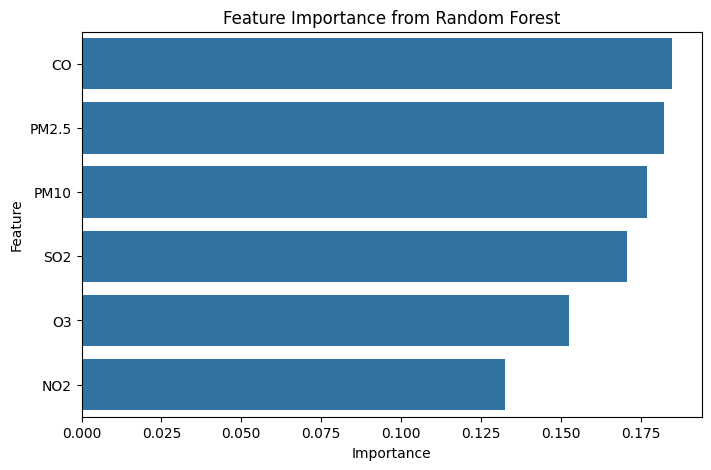

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)
plt.title("Feature Importance from Random Forest")
plt.show()

**comparison**


In [34]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse, rmse_rf],
    'R2 Score': [r2, r2_rf]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,1.055786e-13,1.000000
1,Random Forest,1.187367e-01,0.999999


**Interpretation:**  
Random Forest outperforms Linear Regression with a higher R² score and lower RMSE, indicating better predictive performance.

In [35]:
pip install shap

In [36]:
import shap

## 5. Explainable AI Using SHAP

SHAP (SHapley Additive exPlanations) was applied to interpret model predictions and identify the contribution of each pollutant to AQI levels.


In [37]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

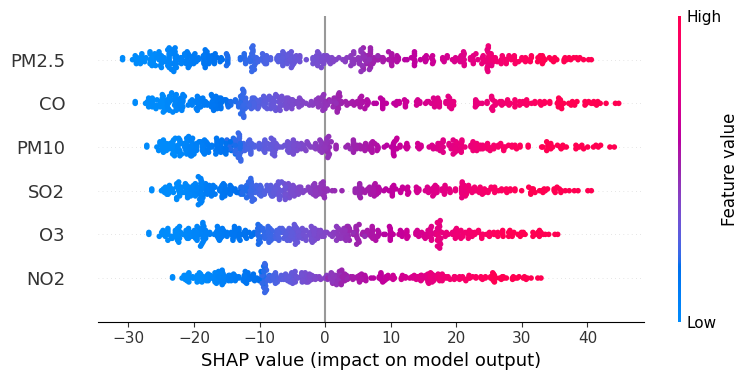

In [38]:
shap.summary_plot(shap_values, X_test)

**Insight:**  
PM2.5 has the highest overall impact on AQI predictions, followed by PM10 and NO₂

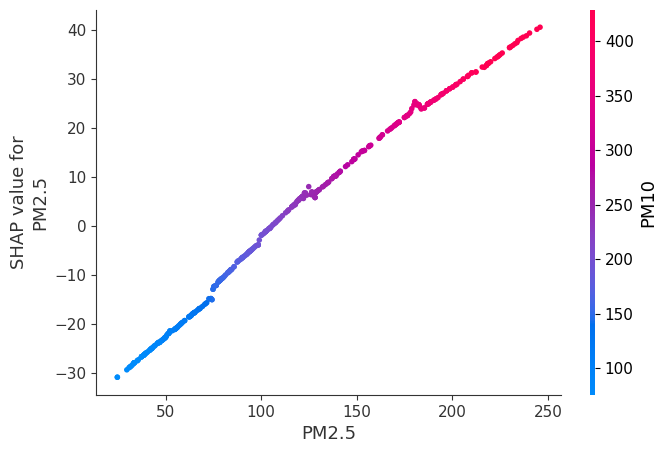

In [39]:
shap.dependence_plot(
    "PM2.5",
    shap_values,
    X_test
)

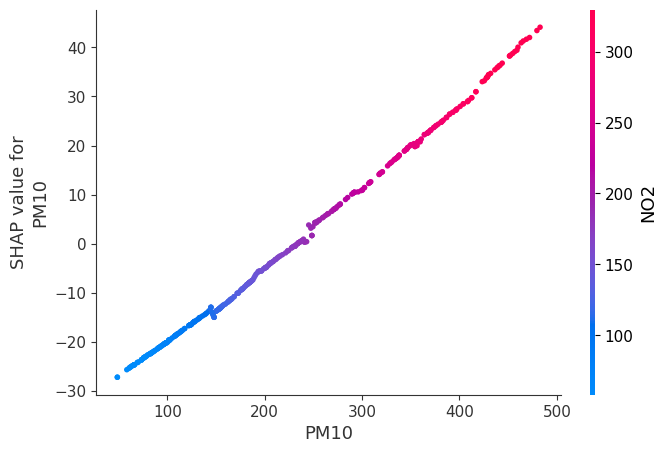

In [40]:
shap.dependence_plot(
    "PM10",
    shap_values,
    X_test
)

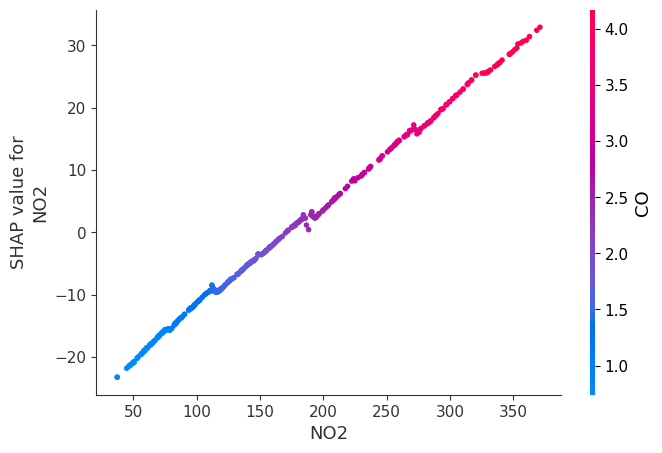

In [41]:
shap.dependence_plot(
    "NO2",
    shap_values,
    X_test
)

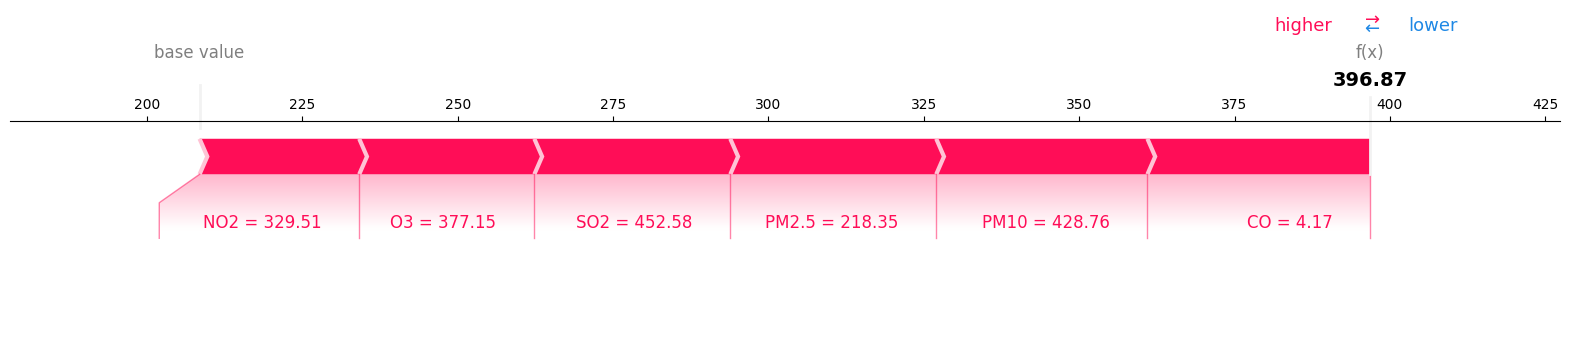

In [42]:
index = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test.iloc[index],
    matplotlib=True
)

In [43]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", round(r2,3))
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

R2 Score: 1.0
MAE: 0.0
RMSE: 0.0


In [44]:
y_pred = lr.predict(X_test)

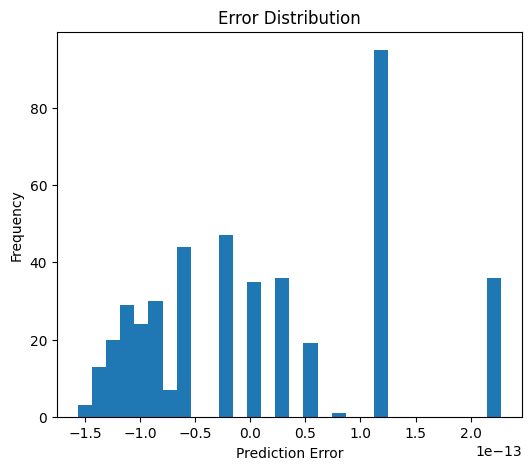

In [45]:
errors = y_test - y_pred

plt.figure(figsize=(6,5))
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()


In [46]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np

pm25 = widgets.FloatText(description='PM2.5')
pm10 = widgets.FloatText(description='PM10')
no2  = widgets.FloatText(description='NO2')
so2  = widgets.FloatText(description='SO2')
co   = widgets.FloatText(description='CO')
o3   = widgets.FloatText(description='O3')

button = widgets.Button(description="Predict AQI")
output = widgets.Output()

def predict_aqi(b):
    with output:
        output.clear_output()

        # Input data
        input_data = pd.DataFrame([{
            'PM2.5': pm25.value,
            'PM10': pm10.value,
            'NO2': no2.value,
            'SO2': so2.value,
            'CO': co.value,
            'O3': o3.value
        }])

        # Predicted AQI
        predicted = lr.predict(input_data)[0]

        # Find closest actual record from dataset
        distances = np.sqrt(((X - input_data.values)**2).sum(axis=1))
        closest_index = distances.idxmin()
        actual = y.loc[closest_index]

        print("🔹 Predicted AQI:", round(predicted,2))
        print("🔹 Actual AQI (from dataset):", round(actual,2))

        # AQI Category
        avg_val = (predicted + actual) / 2

        if avg_val <= 50:
            print("Category: Good")
        elif avg_val <= 100:
            print("Category: Moderate")
        elif avg_val <= 200:
            print("Category: Poor")
        elif avg_val <= 300:
            print("Category: Very Poor")
        else:
            print("Category: Severe")

button.on_click(predict_aqi)

display(pm25, pm10, no2, so2, co, o3, button, output)

FloatText(value=0.0, description='PM2.5')

FloatText(value=0.0, description='PM10')

FloatText(value=0.0, description='NO2')

FloatText(value=0.0, description='SO2')

FloatText(value=0.0, description='CO')

FloatText(value=0.0, description='O3')

Button(description='Predict AQI', style=ButtonStyle())

Output()